# Experiments & Ablations

The evidence behind every design choice in `src/`:

- Protocol: `RepeatedStratifiedKFold(5×3)` from `src/config.make_cv()` — 15 fits per
  configuration, stable on 1,000 rows, preserves the 17.4% default rate in every fold. More Robust.
- Metrics: ROC-AUC (primary, ranking), PR-AUC (rare-positive precision), Brier
  (probability calibration — credit decisions consume the *probability*).

| Axis | Question |
|---|---|
| A. Features | Do narratives (phrase flags / embeddings) or engineered ratios add signal over the raw financials? |
| B. Model family | Which algorithm fits this risk function best? |
| C. Imbalance | Does class weighting help — and what does it cost? |
| D. Calibration | Does a calibration wrapper improve the probabilities? |

Candidates rejected here stay out of `src/`; the winner is exactly what `src/model.py`
implements.

In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.config import (CATEGORICAL, LR_C, NUMERIC, OUT_DIR, RANDOM_STATE, TARGET,
                        TEXT, make_cv)
from src.data import load_training

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

train = load_training()
y = train[TARGET]
RESULTS = []


def bench(axis: str, name: str, estimator, X) -> dict:
    """Shared harness: every experiment goes through the same CV and metrics."""
    sc = cross_validate(estimator, X, y, cv=make_cv(), n_jobs=-1,
                        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision",
                                 "brier": "neg_brier_score"})
    row = {"axis": axis, "config": name,
           "roc_auc": sc["test_roc_auc"].mean(), "roc_auc_std": sc["test_roc_auc"].std(),
           "pr_auc": sc["test_pr_auc"].mean(), "brier": -sc["test_brier"].mean()}
    RESULTS.append(row)
    print(f"[{axis}] {name:34s} AUC={row['roc_auc']:.3f}±{row['roc_auc_std']:.3f}  "
          f"PR={row['pr_auc']:.3f}  Brier={row['brier']:.3f}")
    return row


def pipe_for(model, num_cols, cat_cols, scale=True) -> Pipeline:
    """Same pattern as src/model.make_model(), parameterised for experiments."""
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    transformers = [("num", Pipeline(num_steps), num_cols)]
    if cat_cols:
        transformers.append(("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols))
    return Pipeline([("prep", ColumnTransformer(transformers)), ("model", model)])


def lr():
    return LogisticRegression(C=LR_C, max_iter=3000, random_state=RANDOM_STATE)


print(f"{len(train)} companies, default rate {y.mean():.1%}, CV = 5 folds x 3 repeats")

1000 companies, default rate 17.4%, CV = 5 folds x 3 repeats


## Ablation A — feature representation

Hold the model fixed (regularised logistic regression) and vary only the features.

| # | Config | What it adds |
|---|--------|--------------|
| 1 | Raw tabular | 8 financials + sector/country (**baseline**) |
| 2 | + engineered ratios | leverage×coverage, liquidity stress, productivity, analyst-style flags |
| 3 | + phrase flags | one binary column per templated `faces …` / `benefits from …` phrase |
| 4 | + MiniLM embeddings | `all-MiniLM-L6-v2` (384-d); cached in `outputs/` (label-independent) |
| 5 | Phrases only | falsification test — any narrative signal at all? |
| 6 | Embeddings only | same falsification test |

In [8]:
import re

dfa = train.copy()

# Engineered credit ratios (safe denominators)
dfa["leverage_x_low_coverage"] = dfa["debt_ratio"] / (dfa["interest_coverage"] + 0.1)
dfa["liquidity_stress"] = dfa["debt_ratio"] / (dfa["cash_ratio"] + 0.01)
dfa["profit_per_employee"] = dfa["revenue_m"] * dfa["ebitda_margin"] / (dfa["employee_count"] + 1)
dfa["is_high_leverage"] = (dfa["debt_ratio"] > 0.55).astype(int)
dfa["is_low_coverage"] = (dfa["interest_coverage"] < 2.5).astype(int)
dfa["is_negative_growth"] = (dfa["revenue_growth"] < 0).astype(int)
ENG = ["leverage_x_low_coverage", "liquidity_stress", "profit_per_employee",
       "is_high_leverage", "is_low_coverage", "is_negative_growth"]

# Narrative phrase flags (one column per distinct templated phrase)
phrases = sorted(
    {m.strip().lower() for s in train[TEXT] for m in re.findall(r"faces ([^.]+)", s)}
    | {m.strip().lower() for s in train[TEXT] for m in re.findall(r"benefits from ([^.]+)", s)}
)
text_lower = train[TEXT].str.lower()
phr_df = pd.DataFrame(
    {f"phr_{i}": text_lower.str.contains(re.escape(p)).astype(int) for i, p in enumerate(phrases)},
    index=train.index,
)
PHR = list(phr_df.columns)

# Sentence embeddings (cached: label-independent, so precomputing once is leak-free)
emb_path = OUT_DIR / "emb_minilm.npy"
if emb_path.exists():
    emb = np.load(emb_path)
else:
    from sentence_transformers import SentenceTransformer
    emb = SentenceTransformer("all-MiniLM-L6-v2").encode(
        train[TEXT].tolist(), normalize_embeddings=True, show_progress_bar=False)
    np.save(emb_path, emb)
EMB = [f"emb_{i}" for i in range(emb.shape[1])]
emb_df = pd.DataFrame(emb, columns=EMB, index=train.index)

dfa = pd.concat([dfa, phr_df, emb_df], axis=1)
print(f"{len(ENG)} engineered, {len(PHR)} phrase flags, {emb.shape[1]}-d embeddings\n")

for name, (num_cols, cat_cols) in {
    "raw financials + sector/country": (NUMERIC, CATEGORICAL),
    "+ engineered ratios":             (NUMERIC + ENG, CATEGORICAL),
    "+ narrative phrase flags":        (NUMERIC + PHR, CATEGORICAL),
    "+ MiniLM embeddings":             (NUMERIC + EMB, CATEGORICAL),
    "phrase flags only":               (PHR, []),
    "embeddings only":                 (EMB, []),
}.items():
    bench("A.features", name, pipe_for(lr(), num_cols, cat_cols), dfa[num_cols + cat_cols])

6 engineered, 17 phrase flags, 384-d embeddings

[A.features] raw financials + sector/country    AUC=0.806±0.034  PR=0.531  Brier=0.114
[A.features] + engineered ratios                AUC=0.800±0.031  PR=0.519  Brier=0.115
[A.features] + narrative phrase flags           AUC=0.782±0.037  PR=0.496  Brier=0.118
[A.features] + MiniLM embeddings                AUC=0.749±0.047  PR=0.434  Brier=0.126
[A.features] phrase flags only                  AUC=0.453±0.045  PR=0.166  Brier=0.148
[A.features] embeddings only                    AUC=0.488±0.049  PR=0.189  Brier=0.155


**Verdict A:** raw financials win (AUC 0.806); engineered ratios add nothing, and text features are near chance alone or hurt when added — so narratives stay out of the model and go into the explanation layer only.

## Ablation B — model family

Fix the features to the winner of A; sweep the model families available in scikit-learn:

In [11]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

X_tab = train[NUMERIC + CATEGORICAL]

zoo = {
    "LogisticRegression (C=0.05)": (lr(), True),
    "GaussianNB":                  (GaussianNB(), True),
    "KNN (k=25)":                  (KNeighborsClassifier(n_neighbors=25), True),
    "SVM (RBF)":                   (CalibratedClassifierCV(SVC(random_state=RANDOM_STATE), ensemble=False), True),
    "RandomForest (400 trees)":    (RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=1), False),
    "GradientBoosting":            (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    "HistGradientBoosting":        (HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
}
for name, (model, scale) in zoo.items():
    bench("B.model", name, pipe_for(model, NUMERIC, CATEGORICAL, scale=scale), X_tab)

[B.model] LogisticRegression (C=0.05)        AUC=0.806±0.034  PR=0.531  Brier=0.114
[B.model] GaussianNB                         AUC=0.667±0.047  PR=0.342  Brier=0.176
[B.model] KNN (k=25)                         AUC=0.753±0.042  PR=0.416  Brier=0.126
[B.model] SVM (RBF)                          AUC=0.747±0.036  PR=0.445  Brier=0.123
[B.model] RandomForest (400 trees)           AUC=0.758±0.035  PR=0.451  Brier=0.123
[B.model] GradientBoosting                   AUC=0.751±0.034  PR=0.432  Brier=0.126
[B.model] HistGradientBoosting               AUC=0.719±0.039  PR=0.395  Brier=0.144


**Verdict B:** logistic regression wins (AUC 0.806) — risk looks roughly linear in the financials, so the best model is also the easiest to audit.

## Ablation C — class imbalance handling

- **Imbalance:** ~17% default vs ~83% non-default (4.7 : 1).
- **Two places to fix it:** in the *loss* (`class_weight='balanced'`) or in the *decision* (threshold in `src/policy.py`).
- **Trade-off:** class weights help catch defaulters in training but **inflate** predicted probabilities — they stop matching the true ~17% base rate.
- **Why it matters:** credit workflows use the probability itself, not just the ranking.
- **This ablation:** same features, same LR — only compare unweighted vs balanced.

In [4]:
weighted = LogisticRegression(C=LR_C, max_iter=3000, class_weight="balanced",
                              random_state=RANDOM_STATE)

bench("C.imbalance", "no weighting (decision-layer handling)",
      pipe_for(lr(), NUMERIC, CATEGORICAL), X_tab)
bench("C.imbalance", "class_weight='balanced'",
      pipe_for(weighted, NUMERIC, CATEGORICAL), X_tab)

[C.imbalance] no weighting (decision-layer handling) AUC=0.806±0.034  PR=0.531  Brier=0.114
[C.imbalance] class_weight='balanced'            AUC=0.803±0.034  PR=0.529  Brier=0.178


{'axis': 'C.imbalance',
 'config': "class_weight='balanced'",
 'roc_auc': np.float64(0.8033670674549485),
 'roc_auc_std': np.float64(0.03414195320736161),
 'pr_auc': np.float64(0.5285950690604372),
 'brier': np.float64(0.17802120633085708)}

**Verdict C:** class weights barely change AUC but worsen Brier (0.114 → 0.178) — imbalance stays in `src/policy.py` via a threshold on honest probabilities.

## Ablation D — probability calibration

If the unweighted model is already well calibrated, a `CalibratedClassifierCV` wrapper is
pure complexity. Check.

In [5]:
from sklearn.calibration import CalibratedClassifierCV

bench("D.calibration", "none",
      pipe_for(lr(), NUMERIC, CATEGORICAL), X_tab)
bench("D.calibration", "sigmoid (Platt)",
      CalibratedClassifierCV(pipe_for(lr(), NUMERIC, CATEGORICAL), method="sigmoid", cv=5), X_tab)
bench("D.calibration", "isotonic",
      CalibratedClassifierCV(pipe_for(lr(), NUMERIC, CATEGORICAL), method="isotonic", cv=5), X_tab)

[D.calibration] none                               AUC=0.806±0.034  PR=0.531  Brier=0.114
[D.calibration] sigmoid (Platt)                    AUC=0.807±0.034  PR=0.532  Brier=0.113
[D.calibration] isotonic                           AUC=0.808±0.034  PR=0.522  Brier=0.113


{'axis': 'D.calibration',
 'config': 'isotonic',
 'roc_auc': np.float64(0.8079422247175613),
 'roc_auc_std': np.float64(0.03445116864381917),
 'pr_auc': np.float64(0.5216197767714682),
 'brier': np.float64(0.11332822129286241)}

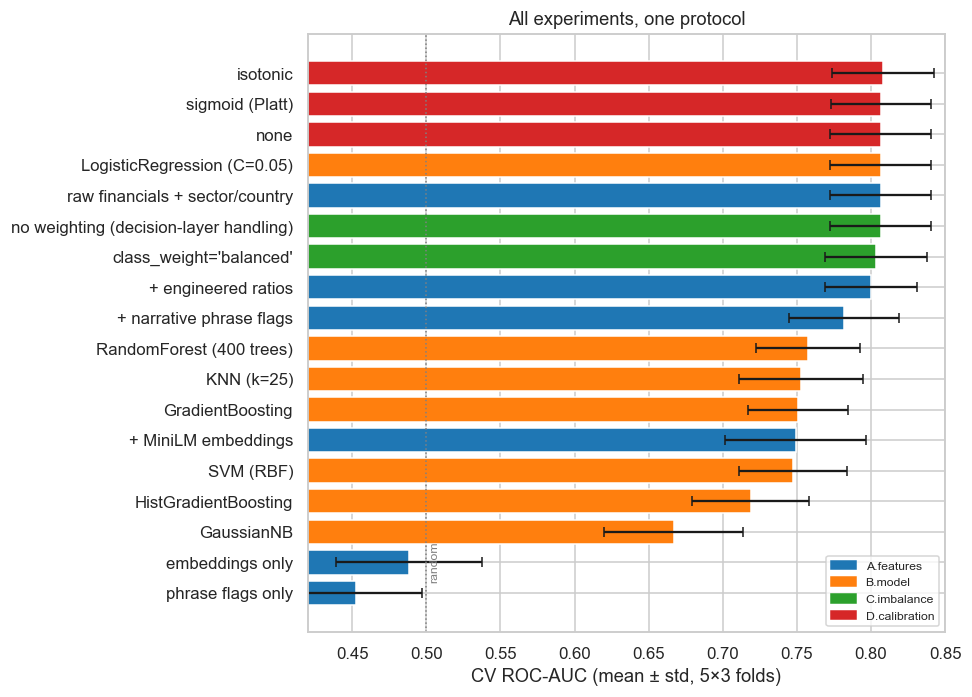

,axis,config,roc_auc,roc_auc_std,pr_auc,brier
0,A.features,raw financials + sector/country,0.806,0.034,0.531,0.114
1,A.features,+ engineered ratios,0.800,0.031,0.519,0.115
2,A.features,+ narrative phrase flags,0.782,0.037,0.496,0.118
3,A.features,+ MiniLM embeddings,0.749,0.047,0.434,0.126
4,A.features,embeddings only,0.488,0.049,0.189,0.155
5,A.features,phrase flags only,0.453,0.045,0.166,0.148
6,B.model,LogisticRegression (C=0.05),0.806,0.034,0.531,0.114
7,B.model,RandomForest (400 trees),0.758,0.035,0.451,0.123
8,B.model,KNN (k=25),0.753,0.042,0.416,0.126
9,B.model,GradientBoosting,0.751,0.034,0.432,0.126


In [6]:
board = (pd.DataFrame(RESULTS)
         .sort_values(["axis", "roc_auc"], ascending=[True, False])
         .reset_index(drop=True))
board.to_csv(OUT_DIR / "experiment_leaderboard.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6.5))
order = board.sort_values("roc_auc")
palette = dict(zip(board["axis"].unique(),
                   sns.color_palette("tab10", board["axis"].nunique())))
ax.barh(order["config"], order["roc_auc"], xerr=order["roc_auc_std"],
        color=[palette[a] for a in order["axis"]], capsize=3)
ax.axvline(0.5, ls=":", color="gray", lw=1)
ax.text(0.502, 0.4, "random", fontsize=8, color="gray", rotation=90)
ax.set_xlim(0.42, 0.85)
ax.set_xlabel("CV ROC-AUC (mean ± std, 5×3 folds)")
ax.set_title("All experiments, one protocol")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

display(board.round(3))

## Decisions promoted to `src/`

| Axis | Decision | Evidence above |
|---|---|---|
| Features | 8 raw financials + sector/country; no engineered ratios; **no text** | A: raw wins; text ≈ chance alone, hurts combined |
| Model | Logistic regression, L2, fixed C=0.05 | B: beats every non-linear family by 4–6 AUC pts |
| Imbalance | **No class weighting** — handled at the decision threshold | C: weighting costs 6 Brier pts for zero AUC |
| Calibration | None needed | D: unweighted LR already at Brier ≈ 0.11 |

The performance ceiling (~0.80–0.81 AUC) is consistent across every family and feature
set — that residual is the synthetic label noise, and we report it honestly rather than
chase it. Next: `03_results.ipynb` evaluates the chosen model in depth and produces the
scored portfolio.